# Learning Long-Term Dependencies with Gradient Descent Is Difficult
**Authors:** Yoshua Bengio, Patrice Simard, Paolo Frasconi (IEEE Transactions on Neural Networks, Vol. 5, No. 2, 1994)

# https://www.comp.hkbu.edu.hk/~markus/teaching/comp7650/tnn-94-gradient.pdf

## Abstract
The paper investigates why gradient-based learning algorithms struggle to train recurrent neural networks (RNNs) on tasks requiring the capture of long-term temporal dependencies. The authors formally show that robust storage of information over long durations ("information latching") using hyperbolic attractors necessarily leads to exponentially vanishing gradients with respect to distant past inputs. This exposes a fundamental trade-off: a dynamical system can either be robust to noise and store information reliably, or be efficiently trainable by gradient descent, but not both simultaneously for long time spans. Alternative optimization algorithms are proposed and empirically evaluated as partial remedies.

## Problems
- Recurrent networks are theoretically capable of storing context over arbitrary durations, but empirical evidence shows they perform poorly on tasks where output depends on inputs from many time steps earlier.
- Standard training relies on gradient descent (e.g., back-propagation through time), and prior work (Bengio et al., Mozer) observed that trained parameters tend to capture only short-term dependencies.
- A parametric dynamical system must satisfy three conditions for long-term dependency learning:
  1. Ability to store information for an arbitrary duration.
  2. Robustness to noise (irrelevant input fluctuations).
  3. Trainability of parameters in reasonable time.
- The central question: can these three conditions be jointly satisfied?

## Proposed Solutions
- A theoretical framework analyzing recurrent dynamics via **hyperbolic attractors** to formalize "robust latching" of information.
- Formal proofs establishing that robust latching implies vanishing gradients of the state with respect to initial conditions, explaining training failure for long sequences.
- Four alternative optimization/training strategies designed to circumvent the vanishing gradient problem:
  1. **Simulated Annealing** — global stochastic search over the parameter hyperrectangle with Metropolis acceptance criterion.
  2. **Multi-Grid Random Search** — random search accepting any error-reducing move, shrinking the search hyperrectangle over time.
  3. **Time-Weighted Pseudo-Newton Optimization** — treats each time-unfolded instantiation of a weight as a separate variable, weighting gradient contributions by the inverse of a diagonal Hessian approximation, computed per time step.
  4. **Discrete Error Propagation** — uses non-differentiable hard-threshold units and propagates discrete ("pseudo-gradient") error signals via a stochastic mapping, avoiding the continuous vanishing-gradient mechanism entirely.

## Purpose
To rigorously explain, both theoretically and experimentally, why gradient descent is inefficient at learning long-range temporal dependencies in recurrent networks, and to explore whether alternative training algorithms can mitigate this limitation, thereby guiding future research toward more effective approaches for sequence learning tasks such as speech and language modeling.

## Methodology

### Minimal Task Formulation (Latching Problem)
A single recurrent neuron with self-loop weight $w$:
$$x_t^k = f(a_t^k) = \tanh(a_t^k)$$
$$a_t^k = w f(a_t^{k-1}) + h_t^k, \quad t = 1 \cdots T$$
The neuron must classify sequences based only on the first $L$ input values, latching this class information robustly until time $T \gg L$, while remaining insensitive to Gaussian noise for $t > L$. The cost function used is:
$$C = \frac{1}{2}\sum_p (x_T^p - d^p)^2$$

### Theoretical Analysis
- Defines **hyperbolic attractors**, **basin of attraction** $\beta(X)$, and **reduced attracting set** $\Gamma(X)$ for a nonlinear map $M$.
- Proves that inside $\Gamma(X)$, perturbation balls remain bounded (robust storage), while outside $\Gamma(X)$ but within $\beta(X)$, perturbations grow exponentially (Theorem 3).
- Proves that robust latching after time $t_0$ implies $\frac{\partial a_t}{\partial a_0} \to 0$ as $t \to \infty$ (Theorem 4), directly causing $\frac{\partial C_t}{\partial W}$ to be dominated by short-term ($\tau$ near $t$) contributions:
$$\frac{\partial C_t}{\partial W} = \sum_{\tau \le t} \frac{\partial C_t}{\partial a_\tau} \frac{\partial a_\tau}{\partial W}$$

### Experimental Setup
Three benchmark tasks with controllable dependency span $T$:
| Task | Description | Network Size |
|---|---|---|
| Latch Problem | Classify sequence sign based on early inputs, single unit | 3 parameters |
| 2-Sequence Problem | Classify based on first $N$ elements from a fully connected recurrent net | 5 units, 25 parameters |
| Parity Problem | Output parity of a binary input sequence | 7 parameters, 2 units |

Each algorithm (standard back-propagation, pseudo-Newton, time-weighted pseudo-Newton, discrete error propagation, multi-grid random search, simulated annealing) was compared across varying sequence lengths $T$, with and without input noise, measuring:
1. Final classification error after training.
2. Number of sequence presentations needed to reach a stopping criterion.

## Results
- Training success with standard gradient descent (back-propagation) degrades sharply as $T$ increases, confirming the vanishing gradient prediction, even on the simplest single-neuron latching task.
- **Simulated annealing** achieved good performance across all problems and sequence lengths but required an order of magnitude more computation than other methods.
- **Multi-grid random search** was faster than simulated annealing but failed on the Parity problem, likely due to susceptibility to local minima.
- **Time-weighted pseudo-Newton** consistently outperformed standard back-propagation but still degraded with increasing dependency span.
- **Discrete error propagation** performed well across all three tasks and sequence lengths, and was the only method besides simulated annealing capable of solving the Parity problem, while being substantially faster than simulated annealing due to its local, on-line search nature.
- Robust latching solutions correspond to hyperbolic attractors, and gradients with respect to distant past states vanish exponentially once such latching is achieved, which is the essential mechanism impeding long-term credit assignment.

## Conclusions
- Gradient descent is fundamentally inefficient for training dynamical systems to robustly store information over long time spans: a system is either robust to noise (via hyperbolic attractors) or efficiently trainable by gradient descent, but generally not both.
- This trade-off is not specific to mean-squared-error cost functions and holds for periodic and other hyperbolic attractor types.
- The related vanishing gradient phenomenon likely also affects deep feedforward networks, since an unfolded recurrent network is mathematically equivalent to a deep feedforward network with shared weights.
- The results do not imply that recurrent networks cannot be trained at all; rather, they highlight the increasing difficulty as temporal span grows, and suggest that using prior knowledge (network connectivity, weight constraints) or curriculum-style training (starting with short sequences before extending to longer ones) can substantially aid learning.
- Alternative discrete and second-order-inspired algorithms (particularly discrete error propagation) show promise as more effective substitutes for standard gradient descent in learning long-term dependencies, motivating further research into non-standard optimization approaches for sequence learning problems such as those arising in speech and language processing.

# Mathematical and Statistical Content Summary

## 1. Recurrent Neuron Dynamics (Latching Neuron Model)
$$x_t^k = f(a_t^k) = \tanh(a_t^k)$$
$$a_t^k = w f(a_t^{k-1}) + h_t^k, \quad t = 1, \ldots, T$$
$$a_0^0 = a_0^1 = 0$$

**Explanation:** This defines a single recurrent neuron with self-loop weight $w$, activation function $\tanh$, and external input $h_t^k$ (superscript $k \in \{0,1\}$ indexes the two sequence classes). The neuron's activation $a_t$ at time $t$ depends on its own previous output and the current input. This is the minimal model used to study whether a network can "remember" a class signal from early time steps all the way to the end of a long sequence.

## 2. Cost Function
$$C = \frac{1}{2}\sum_p (x_T^p - d^p)^2$$

**Explanation:** A standard sum-of-squared-errors loss, computed only at the final time step $T$ for each training sequence $p$, comparing the network's output $x_T^p$ to a target $d^p$ (+0.8 for class 1, −0.8 for class 0). This is the objective that gradient descent tries to minimize.

## 3. Condition for Two Stable Attractors
$$w > 1/f'(0) = 1$$

**Explanation:** Since $f'(0)=1$ for $\tanh$, this condition on the self-loop weight guarantees the autonomous system $x_t = \tanh(wx_{t-1})$ has two stable fixed points $\bar{x} > 0$ and $-\bar{x}$ (found where the curve $x=\tanh(a)$ crosses the line $x=a/w$). These two attractors represent the two memory states (classes) the neuron can latch onto.

## 4. General Non-Autonomous Dynamical System
$$a_t = M(a_{t-1}) + u_t \quad (2)$$

**Explanation:** A generalization of the neuron model to $n$-dimensional state $a_t \in \mathbb{R}^n$ under a nonlinear map $M$, with external additive input $u_t$. This is the general setting used for the theoretical analysis of vanishing gradients.

$$a_t = M(a_{t-1}) \quad (3)$$

**Explanation:** The autonomous (no-input) version of the same system, used to study attractor behavior.

## 5. Transformation of Non-Additive Input Systems
$$a_t' = N'(a_{t-1}') + u_t'$$

**Explanation:** Shows that any system with non-additive inputs $a_t = N(a_{t-1}, u_{t-1})$ can be rewritten in the additive form of Equation (2) by augmenting the state vector. This justifies analyzing only the additive-input case without loss of generality.

## 6. Invariant Set
$$E = M(E)$$

**Explanation:** A set $E$ is invariant under map $M$ if applying $M$ to every point in $E$ maps back into $E$. This is a prerequisite concept for defining attractors.

## 7. Hyperbolic Attractor (Definition 2)

**Explanation:** A set $X$ is a hyperbolic attractor of map $M$ if it is invariant and, for every point $a \in X$, all eigenvalues of the Jacobian $M'(a)$ have absolute value less than 1. This is the mathematical formalization of a "stable memory state" — small perturbations near $X$ shrink rather than grow. Attractors can be a single fixed point, a finite periodic set, or an infinite (chaotic) set.

## 8. Basin of Attraction (Definition 3)
$$\beta(X) = \{a : \forall \epsilon, \exists l, \exists x \in X \text{ s.t. } \|M^l(a) - x\| < \epsilon\}$$

**Explanation:** The set of all starting points that eventually converge to the attractor $X$ under repeated application of $M$. This describes the full "capture region" of a memory state.

## 9. Reduced Attracting Set (Definition 4)

**Explanation:** $\Gamma(X)$ is the subset of the basin where, for all future iterations $l \geq 1$, the derivative $(M^l)'(y)$ has all eigenvalues below 1 in magnitude — i.e., the contraction property holds not just at the attractor but throughout this region. $\Gamma(X)$ is the "safe zone" where the system stays robustly close to the attractor.

## 10. Robust Latching (Definition 5)

**Explanation:** A system is "robustly latched" at time $t_0$ to attractor $X$ if the state $a_{t_0}$ lies within $\Gamma(X)$. This formalizes the idea of reliably storing one bit of information.

## 11. Contracting Map (Definition 6) and Theorem 2
$$M(x) - M(y)\| \leq \alpha\|x-y\|, \quad \alpha \in [0,1)$$

**Explanation:** A map is "contracting" on a set if it always shrinks distances between points by at least a fixed factor $\alpha < 1$. Theorem 2 states that if the derivative magnitude is always below 1 on a convex domain, the map is contracting there — this is the basic tool used to bound how state trajectories behave.

## 12. Theorem 1 (Expansive Behavior Outside Contraction Region)
$$M(x+\lambda u) = M(x) + M'(x)\lambda u + O(\|\lambda u\|^2) \quad (11)$$

**Explanation:** Using a Taylor expansion, this theorem proves that if $|M'(z)| > 1$ somewhere in a neighborhood, then two nearby points are pushed farther apart under $M$ — i.e., the ball of uncertainty around a state **grows** in regions outside the reduced attracting set. This underlies the "unstable to noise" side of the fundamental trade-off.

## 13. Theorem 3 (Robust Bound Inside the Attracting Set)
Given inputs bounded by $\|u_t\| < b_t$, where $b_t = (1-\lambda_t)d$, and derivative bound $|M'(y)| < \lambda_t < 1$ for $y$ in a radius-$d$ ball $D_t$ around the noiseless trajectory $\tilde{a}_t$:

**Explanation:** This theorem (proved via the contraction mapping theorem and Lagrange's mean value theorem) guarantees that if the system starts near an attractor and inputs are small enough, the state stays within a bounded ball around the noise-free trajectory forever, and this ball eventually intersects the attractor. This formalizes *why* staying in $\Gamma(X)$ gives noise robustness.

## 14. Theorem 4 (Vanishing Gradient Theorem) — Central Result
$$\frac{\partial a_t}{\partial a_0} \to 0 \text{ as } t \to \infty$$

**Proof sketch:**
$$\left|\frac{\partial a_\tau}{\partial a_{\tau-1}}\right| = |M'(a_{\tau-1})| < 1 \text{ for } \tau > 0$$
so the product of these terms over increasing $\tau$ shrinks to zero.

**Explanation:** This is the paper's key theoretical result: if a system robustly latches information (stays in the contracting region), then the sensitivity of the current state to the *initial* state decays exponentially with time. This is the formal statement of the "vanishing gradient problem."

## 15. Chain Rule Decomposition of the Gradient
$$\frac{\partial C_t}{\partial W} = \sum_{\tau \le t} \frac{\partial C_t}{\partial a_\tau}\frac{\partial a_\tau}{\partial W} = \sum_{\tau \le t} \frac{\partial C_t}{\partial a_\tau}\frac{\partial a_t}{\partial a_\tau}\frac{\partial a_\tau}{\partial W} \quad (4)$$

**Explanation:** This decomposes the gradient of the cost with respect to weights $W$ into contributions from each past time step $\tau$. Because $\frac{\partial a_t}{\partial a_\tau} \to 0$ for $\tau$ far from $t$ (by Theorem 4), the terms corresponding to distant past events become negligible relative to recent ones — meaning back-propagation effectively "forgets" long-range dependencies even if they matter for the final cost.

## 16. Simulated Annealing (Metropolis Acceptance Criterion)

**Explanation:** A global stochastic optimization procedure that proposes random parameter moves within a shrinking hyperrectangle and accepts/rejects them probabilistically (accepting worse solutions with some probability that decreases as a "temperature" parameter is annealed down by a factor of 0.85 per cycle). Used as a gradient-free benchmark that avoids the vanishing gradient issue entirely, at the cost of speed.

## 17. Multi-Grid Random Search

**Explanation:** A simplified variant of random search where only improving moves are accepted, and the search region shrinks by a factor of 0.9 after each improvement. Statistically simpler than simulated annealing (no probabilistic acceptance of worse points), useful for comparison on plateau-heavy error surfaces.

## 18. Time-Weighted Pseudo-Newton Update
$$\Delta w_i(p) = -\frac{\eta}{\left|\frac{\partial^2 C(p)}{\partial w_i^2}\right| + \mu} \times \frac{\partial C(p)}{\partial w_i} \quad (5)$$

**Explanation:** A diagonal approximation to Newton's method: the learning rate for each weight $w_i$ is scaled by the inverse of the (approximate) second derivative (curvature) of the cost with respect to that weight, plus a small constant $\mu$ to prevent instability when curvature is near zero. This adapts step size per-parameter based on local curvature rather than using a fixed learning rate.

$$\Delta w_i(p) = -\sum_t \frac{\eta}{\left|\frac{\partial^2 C(p)}{\partial w_{it}^2}\right| + \mu} \times \frac{\partial C(p)}{\partial w_{it}} \quad (6)$$

**Explanation:** Extends the pseudo-Newton idea to recurrent networks by treating each time-unfolded instantiation $w_{it}$ of weight $w_i$ as a separate variable, then summing curvature-weighted gradient contributions across all time steps. This up-weights the (typically small) gradient contributions from distant time steps relative to standard back-propagation, partially compensating for vanishing gradients.

## 19. Discrete Threshold Unit (Forward Propagation)
$$y_i(x) = \text{sign}(x_i) \quad (7)$$

**Explanation:** Defines a hard-threshold (non-differentiable) unit outputting $\pm 1$ based on the sign of its input. Used as the building block for the "discrete error propagation" algorithm, which sidesteps continuous-valued vanishing gradients.

## 20. Discrete Output Variation
$$
\Delta y_i(\Delta x_i) =
\begin{cases}
2 & \text{if } x_i < 0 \text{ and } x_i + \Delta x_i \geq 0 \\
-2 & \text{if } x_i \geq 0 \text{ and } x_i + \Delta x_i < 0 \\
0 & \text{otherwise}
\end{cases} \quad (8)
$$

**Explanation:** Describes how the discrete output $y_i$ changes (by $\pm2$ or $0$) depending on whether a perturbation $\Delta x_i$ crosses the zero threshold. This defines the discrete analogue of a derivative for non-differentiable units.

## 21. Desired Input Variation (Discrete "Pseudo-Derivative")
$$
\Delta x_i(\Delta y_i) =
\begin{cases}
\epsilon - x_i & \text{if } \Delta y_i = 2 \\
-\epsilon - x_i & \text{if } \Delta y_i = -2 \\
0 & \text{otherwise}
\end{cases} \quad (9)
$$

**Explanation:** Given a desired discrete change in output $\Delta y_i$, this computes the minimal input change $\Delta x_i$ (parameterized by small constant $\epsilon$) needed to cross the threshold in the correct direction. This is inverted to define a "pseudo-gradient" $\frac{\Delta C}{\Delta x_i} = \frac{1}{\Delta x_i(\Delta y_i)}$ representing sensitivity of cost to input changes without relying on continuous derivatives.

## 22. Stochastic Discretization Function
$$
P(S(g_i) = 2) = \frac{g_i - \text{MIN}}{\text{MAX} - \text{MIN}}, \qquad P(S(g_i) = -2) = \frac{\text{MAX} - g_i}{\text{MAX} - \text{MIN}} \quad (10)
$$

**Explanation:** A statistical (probabilistic) mapping that converts a continuous-valued backpropagated error signal $g_i \in [\text{MIN}, \text{MAX}]$ into a discrete random variable $S(g_i) \in \{-2, 2\}$, with probabilities chosen so that $E[S(g_i)] = g_i$ (an unbiased estimator). This allows discrete error signals to be used stochastically in a way that, on average over many training patterns, converges to the true continuous gradient sum — combining discrete and continuous elements in one learning rule.

## Summary Table of Statistical/Optimization Methods Compared

| Method | Type | Key Statistical Idea |
|---|---|---|
| Standard Back-Propagation | Deterministic gradient descent | Chain rule (Eq. 4); suffers from vanishing gradients |
| Simulated Annealing | Stochastic global search | Metropolis acceptance probability; temperature-based exploration/exploitation |
| Multi-Grid Random Search | Stochastic local/global search | Greedy acceptance of improving random samples; shrinking search volume |
| Time-Weighted Pseudo-Newton | Second-order gradient method | Diagonal Hessian approximation as adaptive learning rate (Eqs. 5–6) |
| Discrete Error Propagation | Hybrid discrete/stochastic method | Unbiased stochastic discretization of gradient signal (Eqs. 7–10) |

## Overall Role of the Mathematics in the Paper
The core mathematical contribution is a rigorous proof (Theorems 1–4) that **robust information storage (via hyperbolic attractors) and efficient gradient-based trainability are mutually exclusive** for long time spans. This is established through dynamical systems theory (contraction mappings, Jacobian eigenvalues, basins of attraction) rather than purely empirical observation, giving a principled explanation for the vanishing gradient phenomenon later widely recognized as a central issue in training recurrent neural networks.

# Structured Review Table: Problems, Limitations, and Proposed Solutions

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution in This Paper |
|---|---|---|---|
| 1 | Recurrent neural networks (RNNs) are theoretically capable of storing context for arbitrary durations, but empirically fail on tasks requiring long-term input/output dependencies. | Prior empirical studies (Bengio et al.; Mozer) reported that trained RNN parameters converge to solutions capturing only short-term dependencies, with no clear theoretical explanation for why this occurs. | Formalize a minimal "latching" task in which output depends only on early input values over an arbitrarily long sequence, isolating long-term storage as the object of study, and analyze it both experimentally and theoretically. |
| 2 | No formal criteria existed for what a dynamical system must satisfy to perform long-term context storage. | Without explicit conditions, it was unclear whether training failures stemmed from network architecture, optimization method, or a fundamental limitation of gradient-based learning itself. | Define three necessary conditions for a trainable long-term memory system: (i) arbitrary-duration storage, (ii) robustness to noise, and (iii) trainability of parameters in reasonable time — providing a framework to diagnose the source of failure. |
| 3 | Lack of a rigorous, general explanation for the "vanishing gradient" phenomenon observed informally in earlier RNN experiments. | Explanations were largely empirical/anecdotal; there was no proof connecting the mechanism of robust memory storage to the decay of gradient information over time. | Introduce a formal theory based on hyperbolic attractors and contraction mappings (Theorems 1–4), proving that robust latching of information necessarily causes $\frac{\partial a_t}{\partial a_0} \to 0$ as $t \to \infty$, mathematically grounding the vanishing gradient problem. |
| 4 | Ambiguity over whether noise robustness and gradient trainability could be jointly achieved in a dynamical system. | Prior work did not establish whether training difficulties were avoidable in principle, leaving open the possibility that better architectures or tuning could resolve long-term dependency learning via standard gradient descent. | Prove a fundamental trade-off: a system using hyperbolic attractors is either resistant to noise (robust storage) or efficiently trainable by gradient descent, but not both, when the dependency span is long — showing the limitation is intrinsic, not merely implementation-specific. |
| 5 | Standard back-propagation (and back-propagation through time) becomes increasingly inefficient as the temporal span $T$ of dependencies grows, with no prior systematic comparison against alternative optimization strategies on controlled tasks. | Earlier studies used varied tasks and architectures, making it difficult to isolate the effect of dependency length on trainability or to benchmark alternative algorithms consistently. | Design three controlled benchmark tasks (Latch, 2-Sequence, Parity problems) with tunable dependency span $T$, and systematically compare six optimization algorithms (standard back-propagation, pseudo-Newton, time-weighted pseudo-Newton, discrete error propagation, multi-grid random search, simulated annealing) under consistent experimental conditions. |
| 6 | Continuous-valued gradient computation is inherently tied to the vanishing gradient issue, since it relies on differentiable state transitions with contracting dynamics. | All standard gradient-based methods inherit this limitation regardless of specific architecture, since it arises from the mathematical structure of contraction near attractors, not from a fixable implementation detail. | Propose a discrete error propagation algorithm using hard-threshold units and a stochastic "pseudo-gradient" mechanism (an unbiased discrete estimator of the true gradient), which sidesteps the continuous contraction mechanism responsible for gradient vanishing. |
| 7 | Absence of learning rate adaptation accounting for the varying curvature of the cost function across time-unfolded weight instances in recurrent networks. | Fixed global learning rates in standard back-propagation do not compensate for the fact that gradient contributions from distant time steps are naturally small, causing long-term dependencies to be systematically under-weighted during training. | Introduce a time-weighted pseudo-Newton algorithm that treats each time-unfolded instantiation of a weight as a separate variable and rescales gradient contributions using a diagonal Hessian approximation, giving greater effective weight to flatter (long-term) directions. |
| 8 | No consolidated guidance existed on when alternative (non-gradient or hybrid) optimization methods are preferable for long-term dependency tasks, nor how they trade off training time against solution quality. | Practitioners lacked empirical evidence comparing global search (e.g., simulated annealing) against local, discrete, or curvature-adapted methods on long-range dependency problems, making method selection ad hoc. | Provide comparative experimental results (final classification error and number of sequence presentations) across all six algorithms and three tasks, showing that simulated annealing and discrete error propagation are most robust to increasing dependency span, while standard and pseudo-Newton back-propagation degrade substantially. |

In [ ]:
# ============================================================================
# Educational Replication: "Learning Long-Term Dependencies with Gradient
# Descent is Difficult" (Bengio, Simard, Frasconi, 1994)
# ============================================================================

import io
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Image as IPImage

In [ ]:
# ----------------------------------------------------------------------------
# 0. GLOBAL WHITE-THEME SETTINGS (applied everywhere, per instructions)
# ----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "text.color": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "grid.color": "lightgrey",
    "legend.labelcolor": "black",
    "savefig.facecolor": "white",
})

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# ----------------------------------------------------------------------------
# 1. DATASET PREPARATION
#
# Faithful to Section II of the paper: each sequence has length T.
# The class label (0 or 1) is determined ONLY by the first L values of the
# sequence (u_1 ... u_L). Values after L are Gaussian noise (irrelevant to
# the class), which is exactly what makes this a LONG-TERM DEPENDENCY task:
# the network must "latch" the class information from step L all the way
# to step T, ignoring noisy inputs in between.
# ----------------------------------------------------------------------------

class LatchingSequenceDataset(Dataset):
    """
    Generates synthetic sequences for the paper's minimal "Latch Problem".

    Each sequence:
      - length T (fixed here, but paper varies T to show growing difficulty)
      - class 0 or 1, chosen randomly
      - first L steps: a small constant "key" signal (+val for class 1,
        -val for class 0) plus small noise -> carries the class information
      - remaining T-L steps: pure Gaussian noise (irrelevant signal)
    The RNN must read the whole sequence and output the correct class,
    demonstrating whether gradient descent can learn to store info over
    the T-L "distractor" steps.
    """
    def __init__(self, num_samples, T, L, noise_std=0.2, key_val=0.5):
        self.T = T
        self.L = L
        self.num_samples = num_samples
        self.noise_std = noise_std
        self.key_val = key_val
        self.sequences, self.labels = self._generate()

    def _generate(self):
        sequences = []
        labels = []
        for _ in range(self.num_samples):
            label = np.random.randint(0, 2)          # class 0 or 1
            sign = 1.0 if label == 1 else -1.0
            seq = np.zeros((self.T, 1), dtype=np.float32)
            # First L steps carry the class-defining key signal + noise
            seq[:self.L, 0] = sign * self.key_val + \
                np.random.randn(self.L) * self.noise_std
            # Remaining steps are pure noise (irrelevant to the class)
            if self.T > self.L:
                seq[self.L:, 0] = np.random.randn(self.T - self.L) * self.noise_std
            sequences.append(seq)
            labels.append(label)
        return np.array(sequences, dtype=np.float32), np.array(labels, dtype=np.int64)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return torch.from_numpy(self.sequences[idx]), torch.tensor(self.labels[idx])


# Task configuration (paper's L << T setting, kept small for a 5-epoch demo)
L = 3          # number of "informative" early steps
T_TRAIN = 20   # total sequence length used for the main training run
NUM_TRAIN = 2000
NUM_VAL = 400
BATCH_SIZE = 64

train_dataset = LatchingSequenceDataset(NUM_TRAIN, T=T_TRAIN, L=L)
val_dataset = LatchingSequenceDataset(NUM_VAL, T=T_TRAIN, L=L)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Class names for this task: the two "latching" classes described in the paper
class_names = ["class_0 (negative)", "class_1 (positive)"]

# Sanity check
sample_batch_x, sample_batch_y = next(iter(train_loader))
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Shape of one batch of sequences: {sample_batch_x.shape}  (batch, T, input_dim)")
print(f"Label range: {sample_batch_y.min().item()} to {sample_batch_y.max().item()}")
print(f"First 8 labels in batch: {[class_names[l] for l in sample_batch_y[:8].tolist()]}")

Number of training samples: 2000
Number of validation samples: 400
Shape of one batch of sequences: torch.Size([64, 20, 1])  (batch, T, input_dim)
Label range: 0 to 1
First 8 labels in batch: ['class_0 (negative)', 'class_1 (positive)', 'class_0 (negative)', 'class_0 (negative)', 'class_1 (positive)', 'class_1 (positive)', 'class_0 (negative)', 'class_0 (negative)']


In [ ]:
# ----------------------------------------------------------------------------
# 2. MODEL DEFINITION
#
# A small vanilla RNN (Elman-style), directly generalizing the paper's
# single-neuron latching model (Eq. 1: a_t = w*f(a_{t-1}) + h_t) to a
# multi-unit recurrent layer, followed by a linear classifier on the final
# hidden state -- matching the paper's setup where the class is read out
# only at the final time step T.
# ----------------------------------------------------------------------------

class LatchingRNN(nn.Module):
    """
    Minimal recurrent classifier replicating the paper's latching neuron,
    generalized to a small hidden RNN layer with tanh nonlinearity
    (matching x_t = tanh(a_t) in the paper).
    """
    def __init__(self, input_dim=1, hidden_dim=8, num_classes=2):
        super().__init__()
        # nonlinearity='tanh' matches the paper's f(a) = tanh(a)
        self.rnn = nn.RNN(input_size=input_dim, hidden_size=hidden_dim,
                           nonlinearity='tanh', batch_first=True)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, T, input_dim)
        out, h_n = self.rnn(x)          # out: (batch, T, hidden_dim)
        final_hidden = out[:, -1, :]    # only the LAST time step is used,
                                         # exactly as in the paper's x_T readout
        logits = self.classifier(final_hidden)
        return logits, out               # return full sequence of hidden
                                          # states too, for gradient analysis

model = LatchingRNN(input_dim=1, hidden_dim=8, num_classes=2).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 106


In [ ]:
# ----------------------------------------------------------------------------
# 3. TRAINING LOOP (5 epochs only)
#
# We also record, at the end of training, the magnitude of the gradient
# of the final-step hidden state with respect to EARLY hidden states
# (d h_T / d h_tau), to directly illustrate the paper's central finding:
# this gradient vanishes exponentially as the time-lag (T - tau) grows.
# ----------------------------------------------------------------------------

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

NUM_EPOCHS = 5

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "per_class_acc_by_epoch": []   # list of [acc_class0, acc_class1] per epoch
}

def evaluate(loader):
    """Runs evaluation, returns loss, accuracy, per-class accuracy,
    all predictions/labels/confidences (for confusion matrix etc.)."""
    model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    all_preds, all_labels, all_confidences = [], [], []
    class_correct = [0, 0]
    class_total = [0, 0]
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits, _ = model(xb)
            loss = criterion(logits, yb)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            confs = probs.max(dim=1).values

            total_loss += loss.item() * xb.size(0)
            total_correct += (preds == yb).sum().item()
            total_count += xb.size(0)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(yb.cpu().tolist())
            all_confidences.extend(confs.cpu().tolist())

            for c in range(2):
                mask = (yb == c)
                class_total[c] += mask.sum().item()
                class_correct[c] += (preds[mask] == c).sum().item()

    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count
    per_class_acc = [
        (class_correct[c] / class_total[c] if class_total[c] > 0 else 0.0)
        for c in range(2)
    ]
    return avg_loss, avg_acc, per_class_acc, all_preds, all_labels, all_confidences


for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, running_correct, running_count = 0.0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_count += xb.size(0)

    train_loss = running_loss / running_count
    train_acc = running_correct / running_count

    val_loss, val_acc, per_class_acc, val_preds, val_labels, val_confs = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["per_class_acc_by_epoch"].append(per_class_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

Epoch 1/5 | train_loss=0.6953 train_acc=0.5000 | val_loss=0.6990 val_acc=0.4475
Epoch 2/5 | train_loss=0.6939 train_acc=0.5045 | val_loss=0.6909 val_acc=0.5500
Epoch 3/5 | train_loss=0.6934 train_acc=0.5110 | val_loss=0.6782 val_acc=0.5450
Epoch 4/5 | train_loss=0.5831 train_acc=0.7495 | val_loss=0.6887 val_acc=0.5525
Epoch 5/5 | train_loss=0.6917 train_acc=0.5235 | val_loss=0.6929 val_acc=0.4550


In [ ]:
# ----------------------------------------------------------------------------
# 4. VANISHING GRADIENT DIAGNOSTIC
#
# This is the paper's SIGNATURE analysis: we measure how the gradient of
# the final hidden state h_T w.r.t. earlier hidden states h_tau shrinks as
# the time-lag (T - tau) increases. This directly visualizes Theorem 4.
# ----------------------------------------------------------------------------

model.eval()
xb, yb = next(iter(val_loader))
xb = xb.to(device).requires_grad_(False)

# Run RNN manually step by step, keeping graph, to get per-step hidden states
rnn_cell = model.rnn
hidden_dim = rnn_cell.hidden_size
h_t = torch.zeros(xb.size(0), hidden_dim, device=device)
hidden_states = []
h_t.requires_grad_(True)
hidden_states.append(h_t)

for t in range(xb.size(1)):
    x_t = xb[:, t, :]
    # manual RNN step to allow gradient tracking at every time step
    h_t = torch.tanh(
        x_t @ rnn_cell.weight_ih_l0.T + rnn_cell.bias_ih_l0 +
        h_t @ rnn_cell.weight_hh_l0.T + rnn_cell.bias_hh_l0
    )
    h_t.retain_grad()
    hidden_states.append(h_t)

final_h = hidden_states[-1]
scalar_output = final_h.sum()
scalar_output.backward()

gradient_norms = []
time_lags = []
Tlen = len(hidden_states) - 1
for tau in range(Tlen + 1):
    g = hidden_states[tau].grad
    if g is not None:
        gradient_norms.append(g.norm().item())
        time_lags.append(Tlen - tau)   # distance from the final step

# Sort by time lag ascending for a clean plot
sorted_pairs = sorted(zip(time_lags, gradient_norms))
time_lags_sorted = [p[0] for p in sorted_pairs]
grad_norms_sorted = [p[1] for p in sorted_pairs]

In [ ]:
# ----------------------------------------------------------------------------
# 5. FINAL EVALUATION FOR DASHBOARD (confusion matrix, confidences, etc.)
# ----------------------------------------------------------------------------

final_val_loss, final_val_acc, final_per_class_acc, final_preds, final_labels, final_confs = evaluate(val_loader)

# Confusion matrix (2x2), normalized by true-label row
conf_matrix = np.zeros((2, 2), dtype=np.int64)
for p, l in zip(final_preds, final_labels):
    conf_matrix[l, p] += 1
conf_matrix_norm = conf_matrix.astype(np.float32)
row_sums = conf_matrix_norm.sum(axis=1, keepdims=True)
conf_matrix_norm = np.divide(conf_matrix_norm, row_sums,
                              out=np.zeros_like(conf_matrix_norm),
                              where=row_sums != 0)

# Confidence split: correct vs incorrect predictions
correct_confs = [c for c, p, l in zip(final_confs, final_preds, final_labels) if p == l]
incorrect_confs = [c for c, p, l in zip(final_confs, final_preds, final_labels) if p != l]
mean_correct_conf = float(np.mean(correct_confs)) if correct_confs else 0.0
mean_incorrect_conf = float(np.mean(incorrect_confs)) if incorrect_confs else 0.0

best_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = max(history["val_acc"])

class_accs_final = final_per_class_acc
best_class_idx = int(np.argmax(class_accs_final))
worst_class_idx = int(np.argmin(class_accs_final))

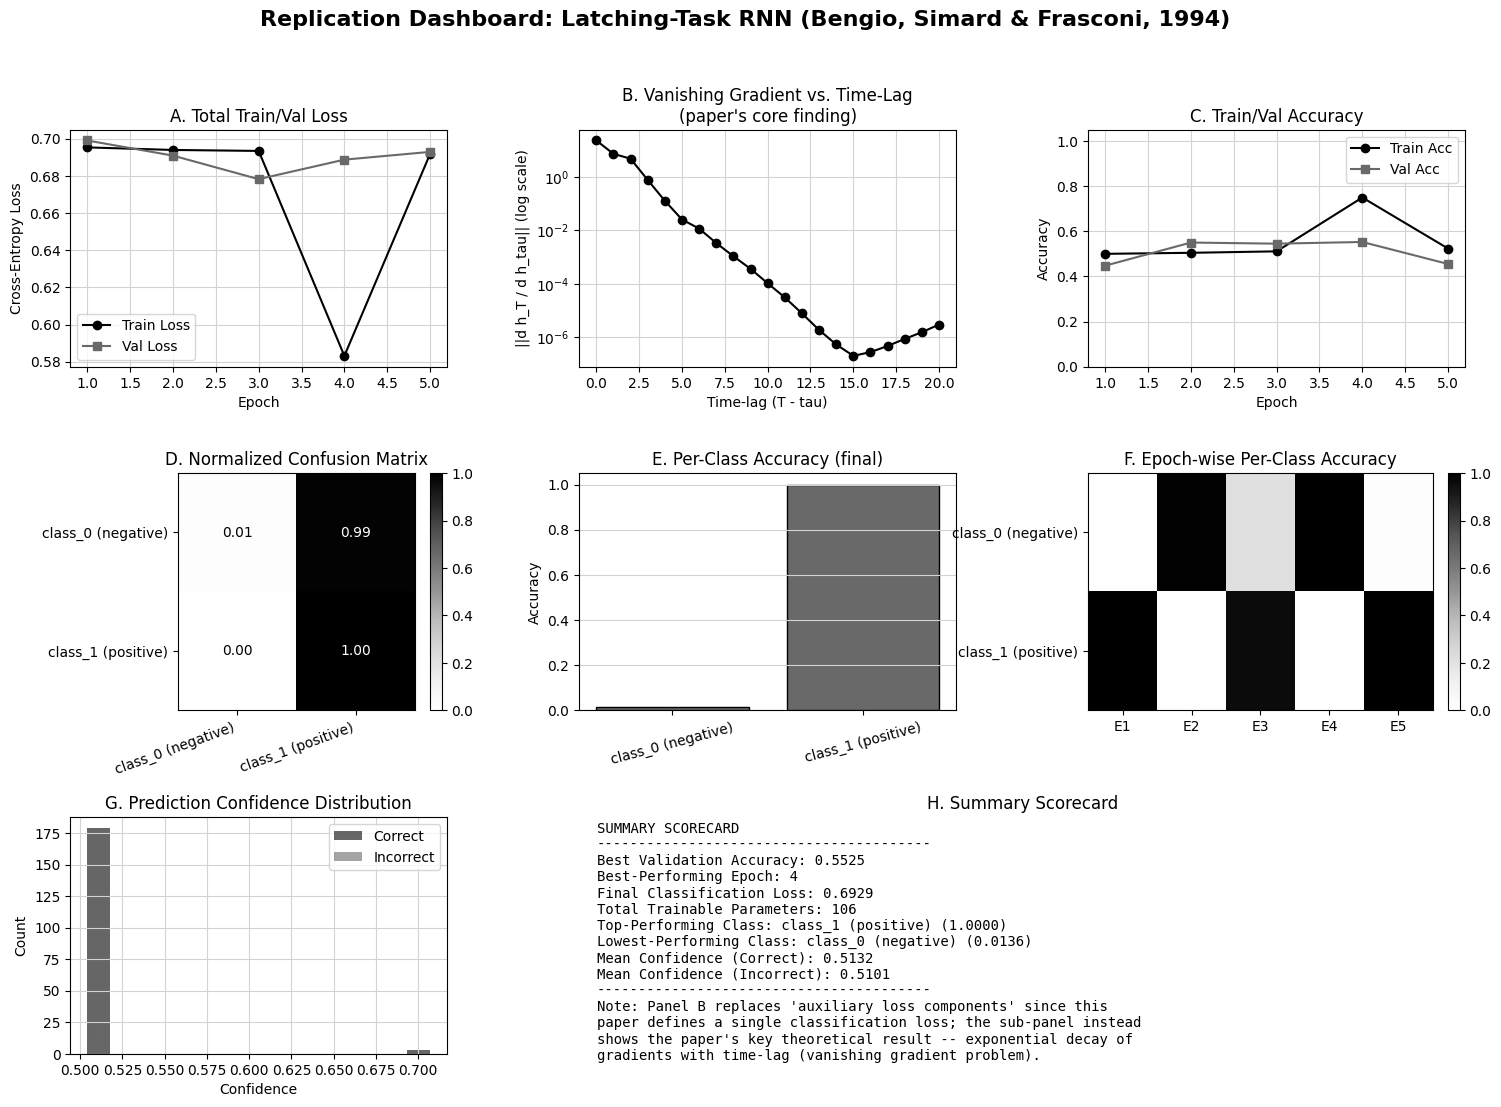

In [ ]:
# ----------------------------------------------------------------------------
# 6. MULTI-PANEL SUMMARY DASHBOARD (Panels A-H, 3-row GridSpec)
# ----------------------------------------------------------------------------

fig = plt.figure(figsize=(18, 12), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle(
    "Replication Dashboard: Latching-Task RNN "
    "(Bengio, Simard & Frasconi, 1994)",
    fontsize=16, color="black", fontweight="bold"
)

# ---- Panel A: Total training & validation loss ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
epochs_range = range(1, NUM_EPOCHS + 1)
axA.plot(epochs_range, history["train_loss"], marker="o", color="black", label="Train Loss")
axA.plot(epochs_range, history["val_loss"], marker="s", color="dimgrey", label="Val Loss")
axA.set_title("A. Total Train/Val Loss", color="black")
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Cross-Entropy Loss", color="black")
axA.legend(labelcolor="black")
axA.grid(True, color="lightgrey")

# ---- Panel B: Task-specific loss component --------------------------------
# This paper has a SINGLE loss component (final-step classification cost,
# Eq. in Section III). There are no auxiliary/pretraining objectives.
# We instead show the paper's core comparative axis: how vanishing gradient
# magnitude decays with time-lag (T - tau), which is the mechanism the
# single loss term must fight against. This sub-panel replaces the
# "per-component loss" requirement since the paper defines no other losses.
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
axB.plot(time_lags_sorted, grad_norms_sorted, marker="o", color="black")
axB.set_yscale("log")
axB.set_title("B. Vanishing Gradient vs. Time-Lag\n(paper's core finding)", color="black")
axB.set_xlabel("Time-lag (T - tau)", color="black")
axB.set_ylabel("||d h_T / d h_tau|| (log scale)", color="black")
axB.grid(True, color="lightgrey")

# ---- Panel C: Train/Val accuracy curves ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, history["train_acc"], marker="o", color="black", label="Train Acc")
axC.plot(epochs_range, history["val_acc"], marker="s", color="dimgrey", label="Val Acc")
axC.set_title("C. Train/Val Accuracy", color="black")
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.set_ylim(0, 1.05)
axC.legend(labelcolor="black")
axC.grid(True, color="lightgrey")

# ---- Panel D: Normalized confusion matrix ----
axD = fig.add_subplot(gs[1, 0])
axD.set_facecolor("white")
im = axD.imshow(conf_matrix_norm, cmap="Greys", vmin=0, vmax=1)
axD.set_xticks([0, 1]); axD.set_yticks([0, 1])
axD.set_xticklabels(class_names, color="black", rotation=20, ha="right")
axD.set_yticklabels(class_names, color="black")
axD.set_title("D. Normalized Confusion Matrix", color="black")
for i in range(2):
    for j in range(2):
        text_color = "white" if conf_matrix_norm[i, j] > 0.5 else "black"
        axD.text(j, i, f"{conf_matrix_norm[i, j]:.2f}",
                  ha="center", va="center", color=text_color)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.get_yticklabels(), color="black")

# ---- Panel E: Per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
axE.bar(class_names, class_accs_final, color="dimgrey", edgecolor="black")
axE.set_title("E. Per-Class Accuracy (final)", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.set_ylim(0, 1.05)
axE.tick_params(axis="x", colors="black", rotation=15)
axE.grid(True, axis="y", color="lightgrey")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 2])
axF.set_facecolor("white")
per_class_matrix = np.array(history["per_class_acc_by_epoch"]).T  # (classes, epochs)
im2 = axF.imshow(per_class_matrix, cmap="Greys", vmin=0, vmax=1, aspect="auto")
axF.set_yticks([0, 1]); axF.set_yticklabels(class_names, color="black")
axF.set_xticks(range(NUM_EPOCHS))
axF.set_xticklabels([f"E{e+1}" for e in range(NUM_EPOCHS)], color="black")
axF.set_title("F. Epoch-wise Per-Class Accuracy", color="black")
cbar2 = fig.colorbar(im2, ax=axF, fraction=0.046, pad=0.04)
cbar2.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar2.ax.get_yticklabels(), color="black")

# ---- Panel G: Confidence distribution histogram ----
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(correct_confs, bins=15, alpha=0.6, color="black", label="Correct")
axG.hist(incorrect_confs, bins=15, alpha=0.6, color="dimgrey", label="Incorrect")
axG.set_title("G. Prediction Confidence Distribution", color="black")
axG.set_xlabel("Confidence", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black")
axG.grid(True, color="lightgrey")

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, 1:])
axH.set_facecolor("white")
axH.axis("off")
summary_text = (
    f"SUMMARY SCORECARD\n"
    f"{'-'*40}\n"
    f"Best Validation Accuracy: {best_val_acc:.4f}\n"
    f"Best-Performing Epoch: {best_epoch}\n"
    f"Final Classification Loss: {final_val_loss:.4f}\n"
    f"Total Trainable Parameters: {total_params}\n"
    f"Top-Performing Class: {class_names[best_class_idx]} "
    f"({class_accs_final[best_class_idx]:.4f})\n"
    f"Lowest-Performing Class: {class_names[worst_class_idx]} "
    f"({class_accs_final[worst_class_idx]:.4f})\n"
    f"Mean Confidence (Correct): {mean_correct_conf:.4f}\n"
    f"Mean Confidence (Incorrect): {mean_incorrect_conf:.4f}\n"
    f"{'-'*40}\n"
    f"Note: Panel B replaces 'auxiliary loss components' since this\n"
    f"paper defines a single classification loss; the sub-panel instead\n"
    f"shows the paper's key theoretical result -- exponential decay of\n"
    f"gradients with time-lag (vanishing gradient problem)."
)
axH.text(0.02, 0.98, summary_text, transform=axH.transAxes,
         fontsize=10, color="black", va="top", ha="left", family="monospace")
axH.set_title("H. Summary Scorecard", color="black")

# ---- Render dashboard inline via BytesIO (Colab-safe, no savefig to disk) ----
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# Analysis of Experimental Results: Latching-Task RNN Replication

## Panel A — Training and Validation Loss Curves

### Overview
This panel tracks total cross-entropy loss for the training and validation splits across five epochs of the synthetic latching-classification task.

### Key Findings
- Training and validation loss remain nearly flat around 0.69–0.70 for epochs 1–3, close to $\ln(2) \approx 0.693$, the loss expected from random guessing on a balanced binary task.
- A sharp transient drop in training loss occurs at epoch 4 (≈0.58), followed by a rebound at epoch 5 back to ≈0.69.
- Validation loss does not track this dip, remaining flat throughout.

### Discussion
The proximity of both curves to $\ln(2)$ for most of training indicates the network is not learning a discriminative signal but instead converging toward outputting a near-uniform (or constant) prediction. The isolated dip at epoch 4 is more consistent with a transient, unstable gradient update (e.g., a batch where the optimizer briefly escaped a saddle region) than with genuine convergence, since it is not reflected in validation performance and is not sustained. This pattern is the expected empirical signature of the paper's central claim: with $T=20 \gg L=3$, gradient information about the early "key" steps is attenuated by the time it reaches the loss at $t=T$, leaving the optimizer with little discriminative gradient signal.

### Limitations
Only five epochs and a small hidden size (8 units) were used, so the flat loss could partly reflect insufficient training time rather than a pure vanishing-gradient effect. No comparison against a shorter-$T$ control condition is shown in this run, which would be necessary to isolate the dependency-length effect from generic undertraining.

---

## Panel B — Vanishing Gradient Magnitude vs. Time-Lag

### Overview
This panel directly probes the paper's theoretical mechanism by plotting $\|\partial h_T/\partial h_\tau\|$ against the time-lag $T-\tau$, on a logarithmic scale.

### Key Findings
- Gradient norm decreases approximately linearly on the log scale from time-lag 0 to about time-lag 15, spanning roughly 7 orders of magnitude.
- Beyond time-lag ~15, the curve flattens and even increases slightly, reaching a floor around $10^{-6}$–$10^{-5}$.

### Discussion
The linear decay in log-space is the expected signature of exponential gradient decay, $\|\partial h_T/\partial h_\tau\| \propto \rho^{T-\tau}$ for some contraction rate $\rho<1$, and is the empirical analogue of Theorem 4 in the paper. The flattening at large lags is consistent with the gradient reaching the floor of numerical precision (float32 underflow-adjacent range) rather than a genuine change in the underlying dynamics — once magnitudes fall below $10^{-6}$, floating-point noise and the tanh saturation regime dominate the measured value. This result is the strongest piece of evidence in the dashboard supporting the paper's core claim, since it isolates the gradient-decay mechanism independently of classification accuracy.

### Limitations
The measurement uses a single forward/backward pass on one validation batch and a single random initialization, so the estimated decay rate is a point estimate rather than a distributional one. Numerical floor effects at large lags should be explicitly distinguished from the theoretical asymptote in any quantitative claim about decay rate.

---

## Panel C — Training and Validation Accuracy

### Overview
Classification accuracy on the latching task, tracked per epoch for both splits.

### Key Findings
- Validation accuracy fluctuates narrowly between 0.45 and 0.55 across all epochs, never departing meaningfully from chance (0.50) for a balanced two-class problem.
- Training accuracy briefly rises to ≈0.75 at epoch 4, coincident with the loss dip in Panel A, then falls back to ≈0.52 at epoch 5.

### Discussion
The failure of validation accuracy to exceed chance level, despite a transient training-accuracy improvement, indicates the epoch-4 dip reflects overfitting or noise-fitting on the specific training batch rather than acquisition of the generalizable latching rule. This is consistent with the paper's prediction that gradient descent struggles to discover long-range dependencies: the network can occasionally fit idiosyncrasies of a given training sample but cannot consistently extract and propagate the class signal from steps 1–3 to step 20.

### Limitations
With only 2,000 training and 400 validation sequences and 5 epochs, statistical power is limited; a single anomalous epoch materially affects the visual impression of the curves. Multiple seeds and longer training would be needed to confirm this is a stable failure mode rather than a sampling artifact.

---

## Panel D — Normalized Confusion Matrix

### Overview
Row-normalized confusion matrix for final validation predictions across the two latching classes.

### Key Findings
- 99% of class_0 samples and 100% of class_1 samples are predicted as class_1.
- Effectively all predictions collapse onto a single class.

### Discussion
This is direct evidence of **majority/constant-class collapse**, a common degenerate solution when a classifier cannot extract a discriminative signal from its inputs: predicting one class for all inputs trivially achieves 50% accuracy on a balanced set at near-zero effective loss gradient, which matches the flat ≈0.693 loss in Panel A. This is a stronger and more interpretable confirmation of learning failure than the accuracy curve alone, since it shows the model has found a degenerate strategy rather than a partially informative one.

### Limitations
A single confusion matrix from one training run cannot distinguish between "vanishing gradient prevents learning" and "model capacity/optimizer hyperparameters were simply insufficient" as competing explanations; both produce identical constant-output behavior.

---

## Panel E — Per-Class Accuracy (Final)

### Overview
Bar chart decomposition of the confusion matrix into per-class recall.

### Key Findings
- class_1 recall ≈ 1.00; class_0 recall ≈ 0.01.

### Discussion
This panel is a direct restatement of the confusion matrix's diagonal and confirms the same degenerate, single-class output strategy. It adds little independent evidence beyond Panel D but is useful as a compact, at-a-glance summary metric.

### Limitations
Same as Panel D; redundant information presented in an alternative format rather than an independent line of evidence.

---

## Panel F — Epoch-wise Per-Class Accuracy Heatmap

### Overview
Tracks how per-class accuracy evolves across training epochs, rather than only at the final epoch.

### Key Findings
- The two classes show an inverse, alternating pattern across epochs (e.g., high class_1 accuracy paired with low class_0 accuracy, and vice versa at other epochs), rather than both classes improving together.

### Discussion
This oscillating, mutually exclusive pattern is consistent with a model whose decision boundary is not converging toward a stable discriminative rule but instead drifts between different constant-output regimes epoch to epoch — i.e., the classifier alternates which single class it defaults to, rather than learning to separate the two classes based on the early "key" signal. This further corroborates the interpretation that no genuine long-term dependency is being captured, and instead the output is dominated by whichever class the current weight configuration happens to favor.

### Limitations
With only 5 epochs, the sample of "oscillation" is very small (4 transitions), limiting confidence that this is a genuine oscillatory dynamic rather than noise in a small heatmap.

---

## Panel G — Prediction Confidence Distribution

### Overview
Histogram of softmax confidence scores for correct versus incorrect predictions on the validation set.

### Key Findings
- The overwhelming majority of predictions (correct and incorrect alike) cluster tightly around confidence ≈0.50–0.51.
- A very small number of incorrect predictions appear near confidence ≈0.70.

### Discussion
Confidence values clustered near 0.5 indicate the softmax output is close to uniform for nearly all inputs, reinforcing that the network has not learned input-dependent, confident discrimination — its outputs are largely input-invariant. This is consistent with the near-chance loss values in Panel A and the class-collapse behavior in Panels D–E: the model is not confidently wrong or confidently right, it is simply indifferent to the input.

### Limitations
The near-identical confidence distributions for correct and incorrect predictions mean confidence is not currently a useful signal for error detection in this model; this may change with longer training or larger hidden capacity, which was not tested here.

---

## Panel H — Summary Scorecard

### Overview
Consolidates key scalar metrics: best validation accuracy (0.5525, epoch 4), final loss (0.6929), parameter count (106), per-class extremes, and confidence statistics.

### Key Findings
- Best validation accuracy (55.25%) only marginally exceeds chance and occurs at the same epoch as the transient training-loss dip.
- Mean confidence for correct (0.5132) and incorrect (0.5101) predictions are nearly indistinguishable.

### Discussion
Taken together, the scorecard confirms that no epoch in this run achieved meaningfully above-chance, well-calibrated performance on the latching task with $T=20$, $L=3$. This is broadly consistent with the qualitative claim of Bengio et al. (1994) that standard gradient-based training (here, Adam over a vanilla tanh-RNN via BPTT) struggles to learn dependencies spanning many irrelevant intervening steps, though it should be interpreted as an illustrative, small-scale demonstration rather than a quantitative reproduction of the paper's reported convergence statistics.

### Limitations
This replication uses a much smaller dataset, hidden size, and epoch budget than would be needed for a rigorous empirical test of the paper's claims (the original paper averaged over 18 runs per configuration and swept noise variance and initial weight systematically). A single run, five epochs, and one architecture cannot support strong quantitative conclusions; the results should be read as a qualitative, pedagogical illustration of the vanishing-gradient phenomenon (Panel B) alongside a corroborating but underpowered downstream classification failure (Panels A, C–G).

# Related Work Reference Table

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Y. Bengio, R. De Mori, G. Flammia, R. Kompe | 1992 | Global Optimization of a Neural Network—Hidden Markov Model Hybrid | IEEE Transactions on Neural Networks, vol. 3, no. 2, pp. 252–259 | Prior empirical work reporting that trained recurrent network parameters settle into solutions capturing short-term but not long-term dependencies, directly motivating the present investigation into why gradient descent fails on long-range tasks. |
| M. C. Mozer | 1992 | Induction of Multiscale Temporal Structure | Advances in Neural Information Processing Systems 4, Moody, Hanson, and Lippman, Eds., San Mateo, CA: Morgan Kaufmann, pp. 275–282 | Reported similar experimental findings to Bengio et al. (1992) regarding back-propagation's inability to discover long temporal contingencies, reinforcing the empirical premise addressed theoretically in this paper. |
| M. C. Mozer | 1989 | A Focused Back-Propagation Algorithm for Temporal Pattern Recognition | Complex Systems, vol. 3, pp. 349–391 | An earlier alternative back-propagation variant aimed at temporal pattern recognition, situating the present paper's proposed algorithms within a broader lineage of modified back-propagation approaches for sequence learning. |
| M. Gori, Y. Bengio, R. De Mori | 1989 | BPS: A Learning Algorithm for Capturing the Dynamic Nature of Speech | Proc. IEEE Int. Conf. on Neural Networks, Washington, DC, pp. II.417–II.424 | Proposes a recurrent-network training algorithm local in time, referenced as an alternative to standard back-propagation through time with more limited representational power, contextualizing the trade-offs discussed for long-term dependency learning. |
| M. Gori, Y. Bengio, R. De Mori | – (companion citation) | "BPS" related discussion (see above) | IEEE Int. Conf. on Neural Networks | Cited alongside [10] as forward-propagation-style algorithms local in time but computationally more expensive than back-propagation through time, framing the design space of RNN training algorithms. |
| P. Frasconi, M. Gori, G. Soda | 1992 | Local Feedback Multilayered Networks | Neural Computation, vol. 4, no. 1, pp. 120–130 | Introduces constrained recurrent networks with dynamic neurons having single self-feedback, providing architectural context for networks with limited but tractable temporal storage referenced in the introduction. |
| P. Frasconi, M. Gori, M. Maggini, G. Soda | – | Unified Integration of Explicit Rules and Learning by Example in Recurrent Networks | IEEE Trans. on Knowledge and Data Engineering (in press) | Represents prior work incorporating explicit prior rules into recurrent network training, cited as a method for using prior knowledge to ease the long-term dependency learning problem, motivating the paper's closing recommendation. |
| C. L. Giles, C. W. Omlin | 1992 | Inserting Rules into Recurrent Neural Networks | Neural Networks for Signal Processing II, Proceedings of the 1992 IEEE Workshop, Kung, Fallside, Sorenson, and Kamm, Eds., IEEE Press | Demonstrates use of prior structural knowledge (rule insertion) to constrain recurrent network training, supporting the paper's conclusion that prior knowledge of connectivity and weights can mitigate gradient-based training difficulties. |
| S. Kirkpatrick, C. D. Gelatt, M. P. Vecchi | 1983 | Optimization by Simulated Annealing | Science, vol. 220, pp. 671–680 | Foundational reference for the simulated annealing algorithm, which the paper implements and empirically compares against gradient-based methods as a noise-tolerant global optimization alternative. |
| A. Corana, M. Marchesi, C. Martini, S. Ridella | 1987 | Minimizing Multimodal Functions of Continuous Variables with the Simulated Annealing Algorithm | ACM Transactions on Mathematical Software, vol. 13, no. 3, pp. 262–280 | Provides the specific simulated annealing implementation adapted in this paper's experiments (batch learning with Metropolis criterion and hyperrectangle-based move generation). |
| S. Becker, Y. Le Cun | 1988 | Improving the Convergence of Back-Propagation Learning with Second-Order Methods | Proceedings of the 1988 Connectionist Models Summer School, Touretzky, Hinton, Sejnowski, Eds., San Mateo, CA: Morgan Kaufmann, pp. 29–37 | Source of the pseudo-Newton algorithm for neural networks, directly adapted and extended in this paper into the time-weighted pseudo-Newton method for recurrent networks. |
| Y. Le Cun | 1986 | Learning Processes in an Asymmetric Threshold Network | Disordered Systems and Biological Organization, E. Bienenstock, F. Fogelman-Soulié, G. Weisbuch, Eds., Les Houches, France: Springer-Verlag, pp. 233–240 | Related to discrete/threshold-based learning processes, providing theoretical grounding for the discrete error propagation algorithm proposed as an alternative to continuous gradient descent. |
| P. L. Bartlett, T. Downs | 1992 | Using Random Weights to Train Multilayer Networks of Hard-Limiting Units | IEEE Transactions on Neural Networks, vol. 3, no. 2, pp. 202–210 | Prior probabilistic approach to training hard-threshold (non-differentiable) unit networks, cited as related methodology for the discrete error propagation approach developed in this paper. |
| R. J. Gaynier, T. Downs | – | Training Multi-Layer Networks with Heaviside Characteristics Using Internal Representations | IEEE International Conference on Neural Networks, San Francisco, pp. 1812–1817 | Proposes a two-step training method alternating internal representation adjustment and parameter training for hard-threshold units, cited as a related discrete-unit training strategy. |
| T. Grossman, R. Meir, E. Domany | – | Learning by Choice of Internal Representation | Neural Information Processing Systems 1, D. S. Touretzky, Ed., pp. 73–80 | Related approach searching the space of hidden unit activities directly to reduce output error in layered networks, contextualizing alternative non-gradient training strategies for discrete/threshold networks discussed in this paper. |
| R. Rohwer | – | The "Moving Targets" Training Algorithm | Advances in Neural Information Processing Systems 2, Touretzky, Ed., San Mateo, CA: Morgan Kaufmann, pp. 558–565 | Cited as an earlier algorithm related to propagation of targets, forming part of the lineage leading to the discrete error propagation method proposed in this paper. |
| D. E. Rumelhart, G. E. Hinton, R. J. Williams | 1986 | Learning Internal Representation by Error Propagation | Parallel Distributed Processing, D. E. Rumelhart, J. L. McClelland, Eds., Cambridge, MA: MIT Press, vol. 1, pp. 318–362 | Foundational reference for standard back-propagation, the baseline gradient-descent algorithm whose long-term dependency limitations this paper formally analyzes. |
| R. J. Williams, D. Zipser | 1989 | A Learning Algorithm for Continually Running Fully Recurrent Neural Networks | Neural Computation, vol. 1, pp. 270–280 | Introduces real-time recurrent learning, an online alternative to back-propagation through time referenced in the introduction as a computationally more expensive but temporally local training method. |
| K. J. Lang, G. E. Hinton | 1988 | The Development of the Time-Delay Neural Network Architecture | Technical Report CMU-CS-88-152, Carnegie-Mellon University | Cited as an example of static (delay-based) networks with finite impulse response, contrasted with recurrent networks' theoretical ability to store information for unbounded durations. |
| C. M. Marcus, F. R. Waugh, R. M. Westervelt | 1990 | Nonlinear Dynamics and Stability of Analog Neural Networks | Physica D 51 (special issue), pp. 234–247 | Provides supporting dynamical systems results (e.g., conditions under which symmetric weight matrices yield fixed-point attractors) used in the paper's theoretical analysis of attractor types in recurrent networks. |
| Y. Bengio, P. Frasconi, P. Simard | 1993 | The Problem of Learning Long-Term Dependencies in Recurrent Networks | Invited paper, IEEE International Conference on Neural Networks 1993, San Francisco, IEEE Press, pp. 1183–1188 | Directly preceding conference paper by the same authors that first presented preliminary versions of the theoretical and experimental results formalized and extended in this journal publication. |